## RSTN - Learmonth spectrograph
**A minimum working example of how to read spectroscopic data from the RSTN-Learmonth spectrograph and plot the dynamic spectrum.**

Author: Nicolina Chrysaphi (ORCID: 0000-0002-4389-5540)

Requirements:
- numpy = 2.4.4
- sunpy = 7.1.2
- matplotlib = 3.10.9
- radiospectra = 0.6.1

Note: Sunpy's Fido does not currently support data download from RSTN/Learmonth. This functionality was requested during the Lorentz Center workshop "Bridging Gaps in Heliospheric Radio Data Analyses" and is currently being worked on. The data used in this notebook was downloaded manually.

Data download link: https://downloads.sws.bom.gov.au/wdc/wdc_spec/data/learmonth/raw/

Tested datafile name: LLM241208.srs

In [1]:
import glob
import numpy as np
from sunpy.time import parse_time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from radiospectra.spectrogram import Spectrogram

c:\Users\nchrysaphi\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Locate the datafile:
datafile = glob.glob('.\\data\\LM241208.srs')

# Read the datafile (which is in binary format) using radiospectra:
data = Spectrogram(datafile)

# Extract arrays of interest:
metadata = data.meta
datetime = data.times.value
time = parse_time(datetime, format='isot').utime
freq = data.frequencies.value
signal = data.data
instrument = data.instrument
obs = data.observatory
t_start = data.start_time.value
t_end = data.end_time.value

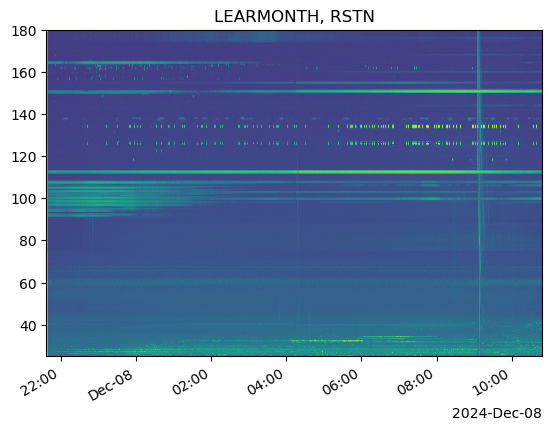

In [3]:
# Plot the dynamic spectrum directly with radiospectra:
data.plot()
plt.show()

In [4]:
# Define slice in frequency and time:
min_f_idx = 40
max_f_idx = 763
min_t_idx = 13000
max_t_idx = 14500
f_slice_idx = 400
t_slice_idx = 13800

# Plots:

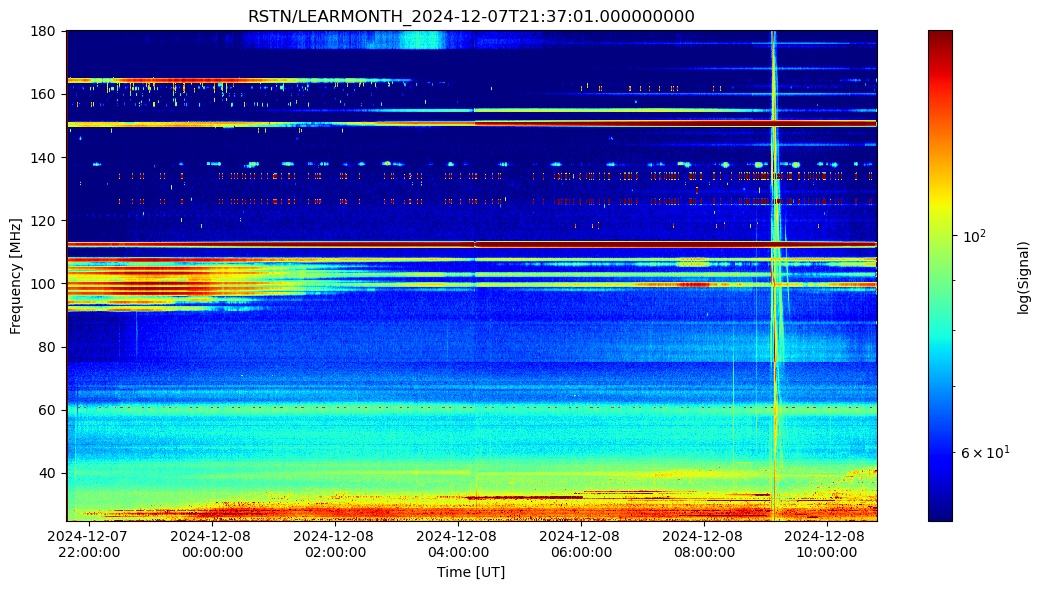

In [5]:
# Plot the dynamic spectrum of the entire dataset:
plt.figure(figsize=(11,6))
plt.pcolormesh(datetime, freq, signal, shading='auto', cmap='jet', norm=LogNorm(vmin=np.nanpercentile(signal, 15), vmax=np.nanpercentile(signal, 99)))
# Axes:
plt.title(f'{instrument}/{obs}_{t_start}')
plt.xlabel("Time [UT]")
plt.ylabel(f'Frequency [{data.frequencies.unit}]')
# Colourbar:
cb=plt.colorbar(orientation="vertical", location="right")
cb.set_label('log(Signal)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter(f"%Y-%m-%d \n%H:%M:%S"))
plt.tight_layout()
plt.show()

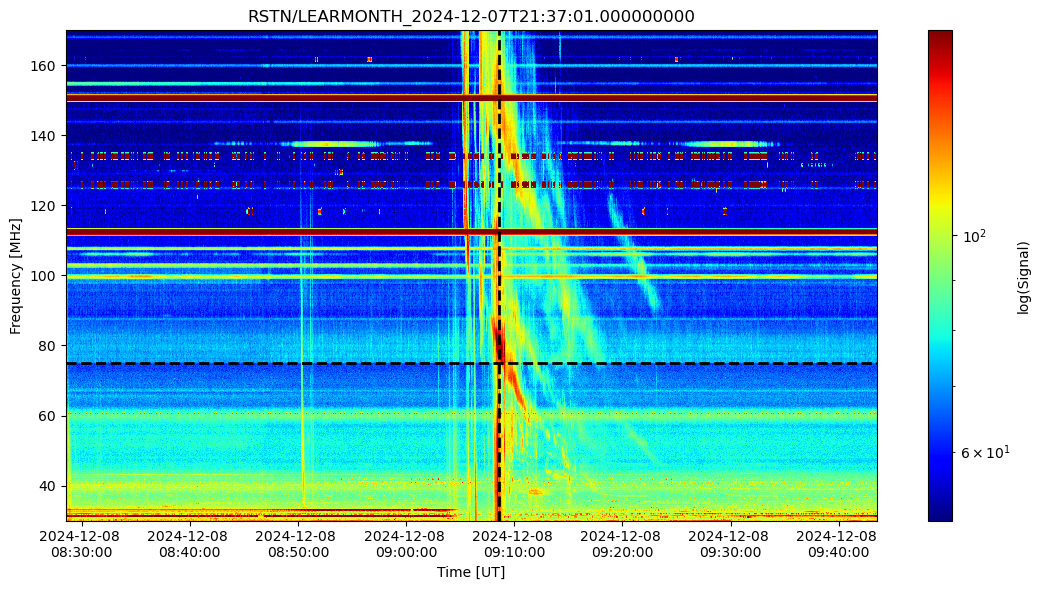

In [6]:
# Plot a zoomed part of the dynamic spectrum:
plt.figure(figsize=(11,6))
plt.pcolormesh(datetime, freq, signal, shading='auto', cmap='jet', norm=LogNorm(vmin=np.nanpercentile(signal, 15), vmax=np.nanpercentile(signal, 99)))
# Labels:
plt.title(f'{instrument}/{obs}_{t_start}')
plt.xlabel("Time [UT]")
plt.ylabel(f'Frequency [{data.frequencies.unit}]')
# Colourbar:
cb=plt.colorbar(orientation="vertical", location="right")
cb.set_label('log(Signal)')
# Axes:
plt.xlim([datetime[min_t_idx], datetime[max_t_idx]])
plt.ylim([freq[min_f_idx], freq[max_f_idx]])
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter(f"%Y-%m-%d \n%H:%M:%S"))
# Plot annotation lines:
plt.axhline(y=freq[f_slice_idx], color='black', linestyle='--', linewidth=2.0)
plt.axvline(x=datetime[t_slice_idx], color='black', linestyle='--', linewidth=2.0)
plt.tight_layout()
plt.show()

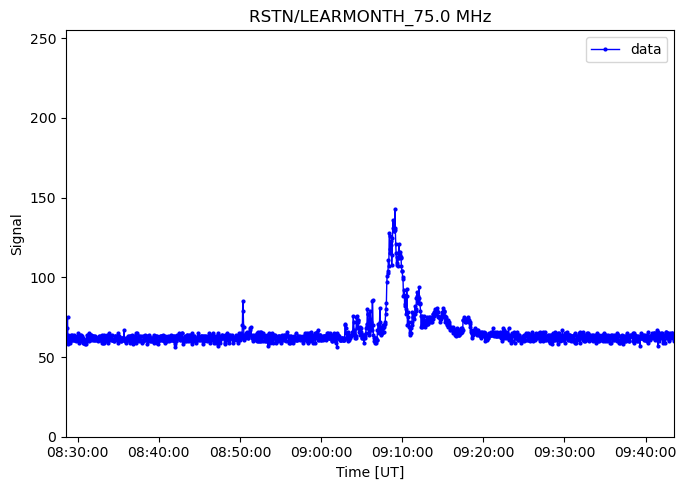

In [7]:
# Plot a light curve (slice across a given frequency):
plt.figure(figsize=(7,5))
plt.plot(datetime, signal[f_slice_idx, :], marker='o', markersize=2, linewidth=1, linestyle='-', color='blue', label='data')
plt.title(f'{instrument}/{obs}_{str(freq[f_slice_idx])} {data.frequencies.unit}')
plt.xlabel('Time [UT]')
plt.ylabel('Signal')
# Axes:
plt.xlim([datetime[min_t_idx], datetime[max_t_idx]])
plt.ylim([np.nanmin(signal), np.nanmax(signal)])
plt.xticks(rotation=0, horizontalalignment='center')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter(f"%H:%M:%S"))
plt.xticks(rotation=0, horizontalalignment='center') #Note: The location of this line matters!
plt.legend()
plt.tight_layout()
plt.show()

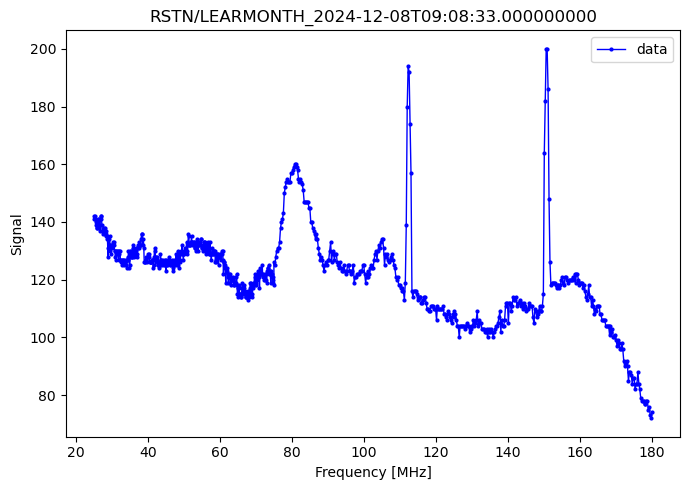

In [8]:
# Plot a spectral line (slice across a given time):
plt.figure(figsize=(7,5))
plt.plot(freq, signal[:, t_slice_idx], marker='o', markersize=2, linewidth=1, linestyle='-', color='blue', label='data')
plt.title(f'{instrument}/{obs}_{str(datetime[t_slice_idx])}')
plt.xlabel(f'Frequency [{data.frequencies.unit}]')
plt.ylabel('Signal')
plt.legend()
plt.tight_layout()
plt.show()